<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/DailyChallenge_BreastCancerPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Ready!")

Ready!


In [60]:
# sklearn imports from Days 1 & 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

print("All imports loaded!")

All imports loaded!


In [61]:
# Daily Challenge: Breast Cancer Prediction

from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
bc_df = pd.DataFrame(data.data, columns=data.feature_names)
bc_df['diagnosis'] = data.target  # 0 = malignant, 1 = benign





In [62]:
# Part A: EDA
# YOUR CODE HERE — explore the data
bc_df.head()
# bc_df.info()
# bc_df.describe()
# bc_df.isnull().sum()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [63]:
# Part B: Preprocessing & Models
# 1. Separate features (X) and target (y)

X = bc_df.drop('diagnosis', axis=1)
y = bc_df['diagnosis']

print(f"Dataset: {len(bc_df)} samples, {X.shape[1]} features")
print(f"Benign rate: {y.mean():.1%}")

Dataset: 569 samples, 30 features
Benign rate: 62.7%


In [64]:
# 2. train_test_split
# Split → Scale → Train → Evaluate (the complete pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on TRAINING
X_test_scaled = scaler.transform(X_test)        # ONLY transform on TEST

print("\nFirst patient BEFORE scaling:")
print(f"  {X_train.iloc[0].to_dict()}")
print(f"\nFirst patient AFTER scaling:")
scaled_row = dict(zip(X_train.columns, X_train_scaled[0].round(3)))
print(f"  {scaled_row}")
print(f"\nColumn means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Column stds  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")



First patient BEFORE scaling:
  {'mean radius': 10.32, 'mean texture': 16.35, 'mean perimeter': 65.31, 'mean area': 324.9, 'mean smoothness': 0.09434, 'mean compactness': 0.04994, 'mean concavity': 0.01012, 'mean concave points': 0.005495, 'mean symmetry': 0.1885, 'mean fractal dimension': 0.06201, 'radius error': 0.2104, 'texture error': 0.967, 'perimeter error': 1.356, 'area error': 12.97, 'smoothness error': 0.007086, 'compactness error': 0.007247, 'concavity error': 0.01012, 'concave points error': 0.005495, 'symmetry error': 0.0156, 'fractal dimension error': 0.002606, 'worst radius': 11.25, 'worst texture': 21.77, 'worst perimeter': 71.12, 'worst area': 384.9, 'worst smoothness': 0.1285, 'worst compactness': 0.08842, 'worst concavity': 0.04384, 'worst concave points': 0.02381, 'worst symmetry': 0.2681, 'worst fractal dimension': 0.07399}

First patient AFTER scaling:
  {'mean radius': np.float64(-1.072), 'mean texture': np.float64(-0.658), 'mean perimeter': np.float64(-1.088), '

In [ ]:
# 4. Train & evaluate:

In [65]:
#    LogisticRegression

logreg = LogisticRegression(max_iter=1000)    # 1. Create
logreg.fit(X_train_scaled, y_train)           # 2. Train
y_pred_logreg = logreg.predict(X_test_scaled) # 3. Predict
print("MODEL TRAINED!")

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_logreg[:10],
    'Match': ['MATCH' if a == p else 'NOT' for a, p in zip(y_test.values[:10], y_pred_logreg[:10])]
})

print()
print("First 10 predictions vs actual:")
display(comparison)

correct = (y_pred_logreg == y_test.values).sum()
total = len(y_test)

print()
print(f"Overall: {correct} correct out of {total} ({correct/total*100:.1f})%")
print(f"Predicted {y_pred_logreg.sum()} malignant - actual {y_test.sum()} malignant")

MODEL TRAINED!

First 10 predictions vs actual:


,Actual,Predicted,Match
0,0,0,MATCH
1,1,1,MATCH
2,0,0,MATCH
3,1,1,MATCH
4,0,0,MATCH
5,1,1,MATCH
6,1,1,MATCH
7,0,0,MATCH
8,0,0,MATCH
9,0,0,MATCH



Overall: 112 correct out of 114 (98.2)%
Predicted 72 malignant - actual 72 malignant


In [18]:
#Verify it worked: check that X_train_scaled.mean(axis=0) is close to 0.
X_train_scaled.mean(axis=0).round(5)

array([-0.,  0., -0.,  0.,  0., -0., -0.,  0., -0., -0.,  0., -0.,  0.,
       -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0., -0.,  0., -0.,
       -0., -0., -0., -0.])

In [22]:
print("LOGISTIC REGRESSION BASELINE")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['malignant', ', benign']))

LOGISTIC REGRESSION BASELINE
Accuracy: 98.25%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
    , benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



1. ACCURACY
  0.9825 (98.2%)
  112 out of 114 predictions correct.
2. Confusion Matrix


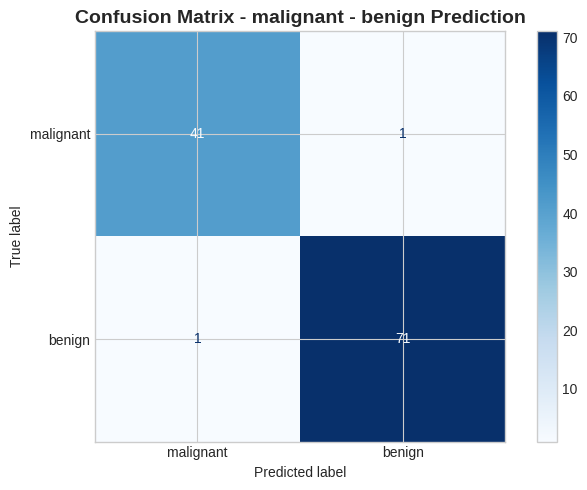


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
# Confusion Matrix
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred_logreg)
print("1. ACCURACY")
print(f"  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  {int(accuracy * len(y_test))} out of {len(y_test)} predictions correct.")

# Confusion matrix
print("2. Confusion Matrix")
fix, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logreg, display_labels=['malignant', 'benign'], cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix - malignant - benign Prediction", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


print()
print(classification_report(y_test, y_pred_logreg, target_names=['malignant', 'benign']))


In [24]:
#    KNeighborsClassifier
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Train KNN with K=5 (default, good starting point)
# WHY K=5? Odd number avoids ties, 5 is a common default
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)  # MUST use scaled data for KNN!

y_pred_knn = knn.predict(X_test_scaled)

print("K-Nearest Neighbors (K=5):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"\nvs Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")

K-Nearest Neighbors (K=5):
Accuracy: 95.61%

vs Logistic Regression: 98.25%


KNN Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



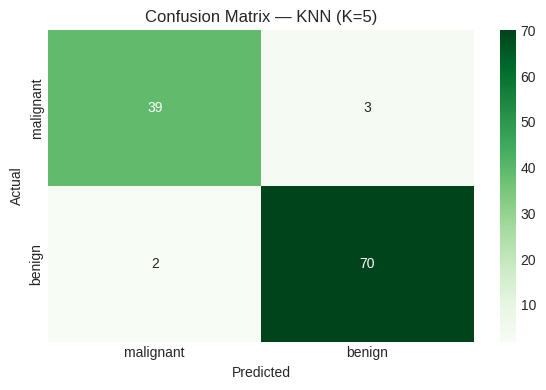

In [25]:
# Full evaluation for KNN
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['malignant', 'benign']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — KNN (K=5)')
plt.tight_layout()
plt.show()

In [26]:
#   SVC = Support Vector Classifier
# Import SVM
from sklearn.svm import SVC

# Train SVM with default settings (RBF kernel)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)  # MUST use scaled data!

y_pred_svm = svm.predict(X_test_scaled)

print("Support Vector Machine (RBF kernel):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")
print(f"\nvs Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"vs KNN (K=5):           {accuracy_score(y_test, y_pred_knn):.2%}")

Support Vector Machine (RBF kernel):
Accuracy: 98.25%

vs Logistic Regression: 98.25%
vs KNN (K=5):           95.61%


In [27]:
#     RandomForestClassifier
# Import and train Random Forest
from sklearn.ensemble import RandomForestClassifier

# IMPORTANT: Random Forest does NOT need scaled data!
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Using X_train, NOT X_train_scaled!

y_pred_rf = rf.predict(X_test)

print("Random Forest (100 trees):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"\nComparison so far:")
print(f"  Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"  KNN (K=5):           {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"  SVM (RBF):           {accuracy_score(y_test, y_pred_svm):.2%}")
print(f"  Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")

Random Forest (100 trees):
Accuracy: 95.61%

Comparison so far:
  Logistic Regression: 98.25%
  KNN (K=5):           95.61%
  SVM (RBF):           98.25%
  Random Forest:       95.61%


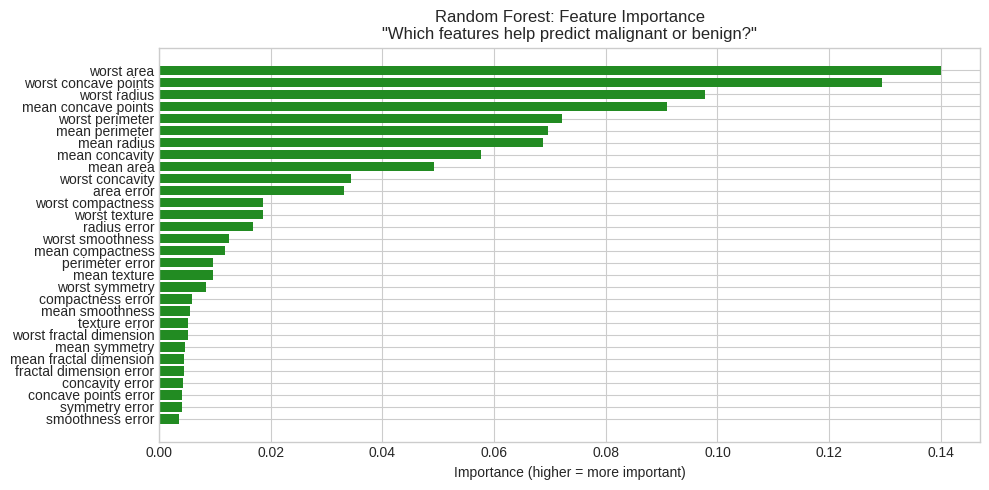


Feature Importance Rankings:
  worst area:		 0.140 ██████████████████████████████████████████████████████████████████████
  worst concave points:		 0.130 ████████████████████████████████████████████████████████████████
  worst radius:		 0.098 ████████████████████████████████████████████████
  mean concave points:		 0.091 █████████████████████████████████████████████
  worst perimeter:		 0.072 ████████████████████████████████████
  mean perimeter:		 0.070 ██████████████████████████████████
  mean radius:		 0.069 ██████████████████████████████████
  mean concavity:		 0.058 ████████████████████████████
  mean area:		 0.049 ████████████████████████
  worst concavity:		 0.034 █████████████████
  area error:		 0.033 ████████████████
  worst compactness:		 0.019 █████████
  worst texture:		 0.019 █████████
  radius error:		 0.017 ████████
  worst smoothness:		 0.012 ██████
  mean compactness:		 0.012 █████
  perimeter error:		 0.010 ████
  mean texture:		 0.010 ████
  worst symmetry:		 0.008

In [32]:
# Feature importance
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel('Importance (higher = more important)')
plt.title('Random Forest: Feature Importance\n"Which features help predict malignant or benign?"')
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = "█" * int(row['Importance'] * 500)
    print(f"  {row['Feature']:8s}:\t\t {row['Importance']:.3f} {bar}")

In [33]:
# XGBoost is an external library (not part of sklearn)
# Install with: pip install xgboost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost imported successfully!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. To install: pip install xgboost")
    print("Skipping XGBoost sections...")

XGBoost imported successfully!


In [34]:
# Train XGBoost
if XGBOOST_AVAILABLE:
    # XGBoost doesn't need scaled data (tree-based)
    xgb = XGBClassifier(
        n_estimators=100,       # Number of boosting rounds (trees)
        learning_rate=0.1,      # How much each tree contributes
        max_depth=5,            # Maximum tree depth
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    print("XGBoost:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
    print(f"\nFull comparison:")
    print(f"  Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")
    print(f"  KNN (K=5):           {accuracy_score(y_test, y_pred_knn):.2%}")
    print(f"  SVM (RBF):           {accuracy_score(y_test, y_pred_svm):.2%}")
    print(f"  Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")
    print(f"  XGBoost:             {accuracy_score(y_test, y_pred_xgb):.2%}")
else:
    print("XGBoost not available — skipping")
    y_pred_xgb = None

XGBoost:
Accuracy: 94.74%

Full comparison:
  Logistic Regression: 98.25%
  KNN (K=5):           95.61%
  SVM (RBF):           98.25%
  Random Forest:       95.61%
  XGBoost:             94.74%


**GridSearchCV**

In [39]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported!")


GridSearchCV imported!


In [43]:
# GridSearchCV for Logistic Regression
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # supports both L1 and L2
}

grid_logreg = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_logreg,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_logreg.fit(X_train_scaled, y_train)

best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg = best_logreg.predict(X_test_scaled)

print(f"Best parameters: {grid_logreg.best_params_}")
print(f"Best CV score:   {grid_logreg.best_score_:.2%}")
print(f"Test score:      {accuracy_score(y_test, y_pred_best_logreg):.2%}")
print(f"vs Default LR:   {accuracy_score(y_test, y_pred_logreg):.2%}")

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score:   98.02%
Test score:      98.25%
vs Default LR:   98.25%


In [40]:
# GridSearchCV for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

n_combos = 6 * 2 * 2  # 24 combinations
print(f"Parameter combinations: {n_combos}")
print(f"Total model fits (5-fold CV): {n_combos * 5}")

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)

print(f"\nBest parameters: {grid_knn.best_params_}")
print(f"Best CV score:   {grid_knn.best_score_:.2%}")
print(f"Test score:      {accuracy_score(y_test, y_pred_best_knn):.2%}")
print(f"vs Manual KNN:   {accuracy_score(y_test, y_pred_knn):.2%}")

Parameter combinations: 24
Total model fits (5-fold CV): 120

Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV score:   96.92%
Test score:      98.25%
vs Manual KNN:   95.61%


In [41]:
# GridSearchCV for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)

print(f"Best parameters: {grid_svm.best_params_}")
print(f"Best CV score:   {grid_svm.best_score_:.2%}")
print(f"Test score:      {accuracy_score(y_test, y_pred_best_svm):.2%}")
print(f"vs Manual SVM:   {accuracy_score(y_test, y_pred_svm):.2%}")

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score:   98.02%
Test score:      98.25%
vs Manual SVM:   98.25%


In [44]:
# GridSearchCV for Random Forest (no scaling needed!)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)  # Unscaled data!

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV score:   {grid_rf.best_score_:.2%}")
print(f"Test score:      {accuracy_score(y_test, y_pred_best_rf):.2%}")
print(f"vs Default RF:   {accuracy_score(y_test, y_pred_rf):.2%}")

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score:   96.04%
Test score:      95.61%
vs Default RF:   95.61%


In [45]:
# GridSearchCV for XGBoost
if XGBOOST_AVAILABLE:
    param_grid_xgb = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }

    grid_xgb = GridSearchCV(
        estimator=XGBClassifier(random_state=42, use_label_encoder=False,
                                eval_metric='logloss'),
        param_grid=param_grid_xgb,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_xgb.fit(X_train, y_train)

    best_xgb = grid_xgb.best_estimator_
    y_pred_best_xgb = best_xgb.predict(X_test)

    print(f"Best parameters: {grid_xgb.best_params_}")
    print(f"Best CV score:   {grid_xgb.best_score_:.2%}")
    print(f"Test score:      {accuracy_score(y_test, y_pred_best_xgb):.2%}")
    if y_pred_xgb is not None:
        print(f"vs Default XGB:  {accuracy_score(y_test, y_pred_xgb):.2%}")
else:
    best_xgb = None
    y_pred_best_xgb = None
    print("XGBoost not available — skipping")

Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best CV score:   97.14%
Test score:      95.61%
vs Default XGB:  94.74%


In [46]:
# Collect all results
results = {
    'Logistic Reg (default)': accuracy_score(y_test, y_pred_logreg),
    'Logistic Reg (tuned)': accuracy_score(y_test, y_pred_best_logreg),
    'KNN (default)': accuracy_score(y_test, y_pred_knn),
    'KNN (tuned)': accuracy_score(y_test, y_pred_best_knn),
    'SVM (default)': accuracy_score(y_test, y_pred_svm),
    'SVM (tuned)': accuracy_score(y_test, y_pred_best_svm),
    'Random Forest (default)': accuracy_score(y_test, y_pred_rf),
    'Random Forest (tuned)': accuracy_score(y_test, y_pred_best_rf),
}

if XGBOOST_AVAILABLE and y_pred_xgb is not None:
    results['XGBoost (default)'] = accuracy_score(y_test, y_pred_xgb)
if XGBOOST_AVAILABLE and y_pred_best_xgb is not None:
    results['XGBoost (tuned)'] = accuracy_score(y_test, y_pred_best_xgb)

# Sort by accuracy
results_sorted = dict(sorted(results.items(), key=lambda x: x[1]))

print("MODEL COMPARISON")
print("=" * 60)
for model, acc in results_sorted.items():
    bar = "█" * int(acc * 50)
    tuned = " ← TUNED" if "tuned" in model else ""
    print(f"  {model:30s}: {acc:.2%} {bar}{tuned}")

MODEL COMPARISON
  XGBoost (default)             : 94.74% ███████████████████████████████████████████████
  KNN (default)                 : 95.61% ███████████████████████████████████████████████
  Random Forest (default)       : 95.61% ███████████████████████████████████████████████
  Random Forest (tuned)         : 95.61% ███████████████████████████████████████████████ ← TUNED
  XGBoost (tuned)               : 95.61% ███████████████████████████████████████████████ ← TUNED
  Logistic Reg (default)        : 98.25% █████████████████████████████████████████████████
  Logistic Reg (tuned)          : 98.25% █████████████████████████████████████████████████ ← TUNED
  KNN (tuned)                   : 98.25% █████████████████████████████████████████████████ ← TUNED
  SVM (default)                 : 98.25% █████████████████████████████████████████████████
  SVM (tuned)                   : 98.25% █████████████████████████████████████████████████ ← TUNED


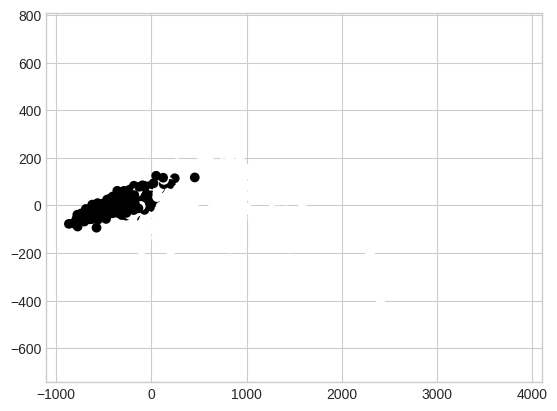

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X2 = PCA(n_components=2).fit_transform(X)

plt.scatter(X2[:,0], X2[:,1], c=y)
plt.show()

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=10000)

scores = cross_val_score(model, X, y, cv=5)

print(scores)

[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]


In [54]:
model.score(X_train, y_train)
model.score(X_test, y_test)

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.